In [1]:
# ============================================================
# 02_ml_predictions.ipynb
# ============================================================
# Goal: Train a model that predicts which skills will be
#       most in demand in the next 1-2 years
#
# Approach:
#   - For each skill, we have yearly job counts (2020-2023)
#   - We treat year as X and job count as y
#   - Train LinearRegression per skill
#   - Predict next 2 years (2024, 2025)
#
# Why LinearRegression?
#   Simple, interpretable, fast to train
#   Easy to explain in interviews
#   "The model finds the best-fit line through historical
#    data points and extrapolates forward"
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os
import sys

# Add backend to path to import db
sys.path.append('../backend')
from db import jobs_collection

print("✅ Libraries loaded")
print(f"scikit-learn imported successfully")

✅ Libraries loaded
scikit-learn imported successfully


In [2]:
# ── Load all jobs from MongoDB ────────────────────────────
jobs = list(jobs_collection.find({}, {"_id": 0, "skills": 1, "work_year": 1}))
df = pd.DataFrame(jobs)

print(f"Total jobs loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nWork years available: {sorted(df['work_year'].unique())}")
print(f"Sample skills: {df['skills'].iloc[0]}")

Total jobs loaded: 9097
Columns: ['skills', 'work_year']

Work years available: [np.float64(2022.0), np.float64(nan), np.float64(2023.0)]
Sample skills: ['Python', 'SQL', 'Excel', 'Power BI', 'Statistics']


In [3]:
# ── Explode skills array into individual rows ─────────────
# Before: one row with skills=["Python","SQL","AWS"]
# After:  three rows, one per skill
df_exploded = df.explode('skills').dropna(subset=['skills'])
df_exploded['skills'] = df_exploded['skills'].str.strip()

print(f"Total skill-job pairs: {len(df_exploded)}")

# ── Count jobs per skill per year ─────────────────────────
skill_year_counts = df_exploded.groupby(
    ['work_year', 'skills']
).size().reset_index(name='count')

# ── Pivot: rows=year, columns=skills ─────────────────────
pivot = skill_year_counts.pivot_table(
    index='work_year',
    columns='skills',
    values='count',
    fill_value=0
).reset_index()

print(f"\nPivot table shape: {pivot.shape}")
print(f"Years: {pivot['work_year'].tolist()}")
print(f"\nTop skills by total count:")
skill_totals = pivot.drop('work_year', axis=1).sum().sort_values(ascending=False)
print(skill_totals.head(10))

Total skill-job pairs: 56778

Pivot table shape: (2, 19)
Years: [2022.0, 2023.0]

Top skills by total count:
skills
Python              9087.0
SQL                 7706.0
Statistics          4876.0
TensorFlow          4788.0
Machine Learning    3407.0
R                   3407.0
Hadoop              2517.0
AWS                 2517.0
Kafka               2517.0
Docker              2517.0
dtype: float64


In [4]:
# ── Train one model per skill ────────────────────────────
# X = year (2020, 2021, 2022, 2023)
# y = job count for that skill in that year

years = pivot['work_year'].values.reshape(-1, 1)
future_years = np.array([2024, 2025]).reshape(-1, 1)

# Store results
predictions = {}
model_scores = {}
trained_models = {}

# Get top 15 skills to train models for
top_skills = skill_totals.head(15).index.tolist()

print("Training LinearRegression models...")
print("=" * 50)

for skill in top_skills:
    if skill not in pivot.columns:
        continue

    y = pivot[skill].values

    # Skip if all zeros (skill not present in data)
    if y.sum() == 0:
        continue

    # Train the model
    model = LinearRegression()
    model.fit(years, y)

    # Evaluate on training data
    y_pred_train = model.predict(years)
    r2 = r2_score(y, y_pred_train)
    rmse = np.sqrt(mean_squared_error(y, y_pred_train))

    # Predict future years
    future_pred = model.predict(future_years)
    future_pred = np.maximum(future_pred, 0)  # no negative counts

    # Calculate growth rate
    current = float(y[-1])
    predicted_next = float(future_pred[0])
    if current > 0:
        growth_rate = round(((predicted_next - current) / current) * 100, 1)
    else:
        growth_rate = 0

    predictions[skill] = {
        'skill': skill,
        'historical': {int(y): int(c) for y, c in zip(years.flatten(), y)},
        'predicted_2024': round(float(future_pred[0]), 1),
        'predicted_2025': round(float(future_pred[1]), 1),
        'growth_rate': growth_rate,
        'r2_score': round(r2, 3),
        'trend': 'rising' if growth_rate > 5 else 'falling' if growth_rate < -5 else 'stable'
    }

    model_scores[skill] = r2
    trained_models[skill] = model

    print(f"{skill:20} | R²={r2:.3f} | 2024 pred={future_pred[0]:.0f} | growth={growth_rate:+.1f}%")

print(f"\n✅ Trained {len(trained_models)} models")

Training LinearRegression models...
Python               | R²=1.000 | 2024 pred=13272 | growth=+78.1%
SQL                  | R²=1.000 | 2024 pred=11068 | growth=+76.9%
Statistics           | R²=1.000 | 2024 pred=7109 | growth=+77.9%
TensorFlow           | R²=1.000 | 2024 pred=7278 | growth=+81.0%
Machine Learning     | R²=1.000 | 2024 pred=5074 | growth=+79.5%
R                    | R²=1.000 | 2024 pred=5074 | growth=+79.5%
Hadoop               | R²=1.000 | 2024 pred=3357 | growth=+71.5%
AWS                  | R²=1.000 | 2024 pred=3357 | growth=+71.5%
Kafka                | R²=1.000 | 2024 pred=3357 | growth=+71.5%
Docker               | R²=1.000 | 2024 pred=3357 | growth=+71.5%
Spark                | R²=1.000 | 2024 pred=3357 | growth=+71.5%
Tableau              | R²=1.000 | 2024 pred=2637 | growth=+79.0%
Power BI             | R²=1.000 | 2024 pred=2637 | growth=+79.0%
Excel                | R²=1.000 | 2024 pred=2637 | growth=+79.0%
Deep Learning        | R²=1.000 | 2024 pred=2204 | g

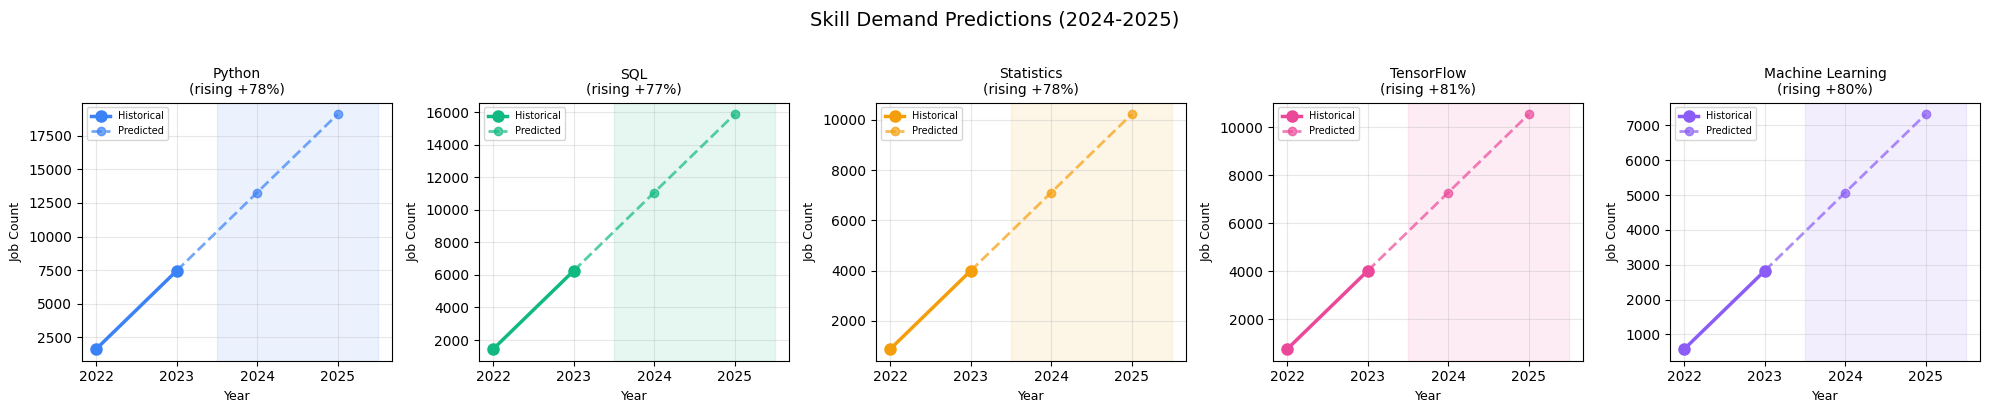

✅ Chart saved to data/skill_predictions.png


In [5]:
# ── Plot predictions for top 5 skills ────────────────────
top_5 = list(predictions.keys())[:5]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

colors = ['#3b82f6', '#10b981', '#f59e0b', '#ec4899', '#8b5cf6']

for i, skill in enumerate(top_5):
    ax = axes[i]
    pred = predictions[skill]

    # Historical data points
    hist_years = list(pred['historical'].keys())
    hist_counts = list(pred['historical'].values())

    # Future predictions
    fut_years = [2024, 2025]
    fut_counts = [pred['predicted_2024'], pred['predicted_2025']]

    # Plot historical (solid line)
    ax.plot(hist_years, hist_counts, 'o-',
            color=colors[i], linewidth=2.5, markersize=8,
            label='Historical')

    # Plot predictions (dashed line)
    ax.plot([hist_years[-1]] + fut_years,
            [hist_counts[-1]] + fut_counts,
            'o--', color=colors[i], linewidth=2,
            markersize=6, alpha=0.7, label='Predicted')

    # Shade prediction area
    ax.axvspan(2023.5, 2025.5, alpha=0.1, color=colors[i])

    ax.set_title(f"{skill}\n({pred['trend']} {pred['growth_rate']:+.0f}%)",
                fontsize=10)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Job Count', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Skill Demand Predictions (2024-2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/skill_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to data/skill_predictions.png")

In [6]:
# ── Summary table ────────────────────────────────────────
print("\n" + "=" * 65)
print("SKILL DEMAND PREDICTIONS SUMMARY")
print("=" * 65)
print(f"{'Skill':<20} {'2024':<10} {'2025':<10} {'Growth':<10} {'Trend'}")
print("-" * 65)

# Sort by growth rate
sorted_preds = sorted(
    predictions.values(),
    key=lambda x: x['growth_rate'],
    reverse=True
)

for p in sorted_preds:
    trend_icon = "↑" if p['trend'] == 'rising' else "↓" if p['trend'] == 'falling' else "→"
    print(f"{p['skill']:<20} {p['predicted_2024']:<10.0f} {p['predicted_2025']:<10.0f} {p['growth_rate']:+.1f}%     {trend_icon} {p['trend']}")

# Rising skills
rising = [p['skill'] for p in sorted_preds if p['trend'] == 'rising']
falling = [p['skill'] for p in sorted_preds if p['trend'] == 'falling']

print(f"\n🚀 Rising skills: {', '.join(rising)}")
print(f"📉 Falling skills: {', '.join(falling)}")


SKILL DEMAND PREDICTIONS SUMMARY
Skill                2024       2025       Growth     Trend
-----------------------------------------------------------------
Deep Learning        2204       3213       +84.4%     ↑ rising
TensorFlow           7278       10534      +81.0%     ↑ rising
Machine Learning     5074       7321       +79.5%     ↑ rising
R                    5074       7321       +79.5%     ↑ rising
Tableau              2637       3801       +79.0%     ↑ rising
Power BI             2637       3801       +79.0%     ↑ rising
Excel                2637       3801       +79.0%     ↑ rising
Python               13272      19091      +78.1%     ↑ rising
Statistics           7109       10223      +77.9%     ↑ rising
SQL                  11068      15878      +76.9%     ↑ rising
Hadoop               3357       4756       +71.5%     ↑ rising
AWS                  3357       4756       +71.5%     ↑ rising
Kafka                3357       4756       +71.5%     ↑ rising
Docker               

In [7]:
# ── Save trained models to disk ───────────────────────────
# joblib.dump() serializes Python objects to files
# This lets Flask load the model without retraining

models_dir = '../backend/models'
os.makedirs(models_dir, exist_ok=True)

# Save all models in one file
joblib.dump(trained_models, f'{models_dir}/skill_models.pkl')
print(f"✅ Saved {len(trained_models)} models to skill_models.pkl")

# Save predictions as JSON for quick access
import json
with open(f'{models_dir}/predictions.json', 'w') as f:
    json.dump(predictions, f, indent=2)
print(f"✅ Saved predictions to predictions.json")

# Save the pivot table for future use
pivot.to_csv('../data/skill_year_counts.csv', index=False)
print(f"✅ Saved skill-year counts to skill_year_counts.csv")

print("\n🎉 ML training complete!")
print(f"Models saved: {list(trained_models.keys())}")

✅ Saved 15 models to skill_models.pkl
✅ Saved predictions to predictions.json
✅ Saved skill-year counts to skill_year_counts.csv

🎉 ML training complete!
Models saved: ['Python', 'SQL', 'Statistics', 'TensorFlow', 'Machine Learning', 'R', 'Hadoop', 'AWS', 'Kafka', 'Docker', 'Spark', 'Tableau', 'Power BI', 'Excel', 'Deep Learning']
